# Spectrogram Processing by Tiny ResNet


In [1]:
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

sys.path.append("/home/rffl/files/eegconv/")
import datagen
import specdataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 50
WEIGHT_DECAY = 1e-4

classvec = [i+1 for i in range(10)]
subvec = [i+1 for i in range(10)]

Using device: cpu


/home/rffl/miniconda3/envs/eeg/lib/python3.11/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [6]:
train_path, test_path = datagen.generatedataset(classvec, subvec, 0.75, 16, 8, False)

Generating spectrograms...
Saved ./train_spec.npy. Shape: (6000, 17, 9, 11)
Saved ./test_spec.npy. Shape: (2000, 17, 9, 11)


In [3]:
from torchvision.models import resnet18

class TinyResNet(nn.Module):
    def __init__(self, num_classes, in_channels=17):
        super(TinyResNet, self).__init__()
        self.model = resnet18(weights=True)
        
        self.model.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3, 
                                     stride=1, padding=1, bias=False)
        
        self.model.maxpool = nn.Identity()
        
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)
        
    def forward(self, x):
        return self.model(x)

In [4]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        correct += (outputs.argmax(1) == y).sum().item()
        total += y.size(0)
    return running_loss / len(loader), correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        outputs = model(X)
        loss = criterion(outputs, y)
        running_loss += loss.item()
        correct += (outputs.argmax(1) == y).sum().item()
        total += y.size(0)
    return running_loss / len(loader), correct / total

Epoch 01: Loss=2.3759 | Train Acc=11.87%| Test Acc=13.65%
Epoch 02: Loss=2.2277 | Train Acc=16.93%| Test Acc=19.20%
Epoch 03: Loss=2.1900 | Train Acc=19.40%| Test Acc=18.00%
Epoch 04: Loss=2.1355 | Train Acc=21.05%| Test Acc=19.55%
Epoch 05: Loss=2.0702 | Train Acc=23.32%| Test Acc=21.60%
Epoch 06: Loss=2.0525 | Train Acc=24.88%| Test Acc=19.15%
Epoch 07: Loss=1.9898 | Train Acc=28.28%| Test Acc=21.15%
Epoch 08: Loss=1.8919 | Train Acc=30.43%| Test Acc=21.20%
Epoch 09: Loss=1.8040 | Train Acc=34.45%| Test Acc=21.25%
Epoch 10: Loss=1.6833 | Train Acc=38.93%| Test Acc=21.30%
Epoch 11: Loss=1.5523 | Train Acc=43.43%| Test Acc=21.45%
Epoch 12: Loss=1.3820 | Train Acc=50.02%| Test Acc=24.70%
Epoch 13: Loss=1.1659 | Train Acc=58.38%| Test Acc=22.65%
Epoch 14: Loss=1.0188 | Train Acc=64.65%| Test Acc=23.60%
Epoch 15: Loss=0.8344 | Train Acc=70.07%| Test Acc=23.50%
Epoch 16: Loss=0.6358 | Train Acc=77.18%| Test Acc=23.65%
Epoch 17: Loss=0.5346 | Train Acc=81.78%| Test Acc=24.00%
Epoch 18: Loss

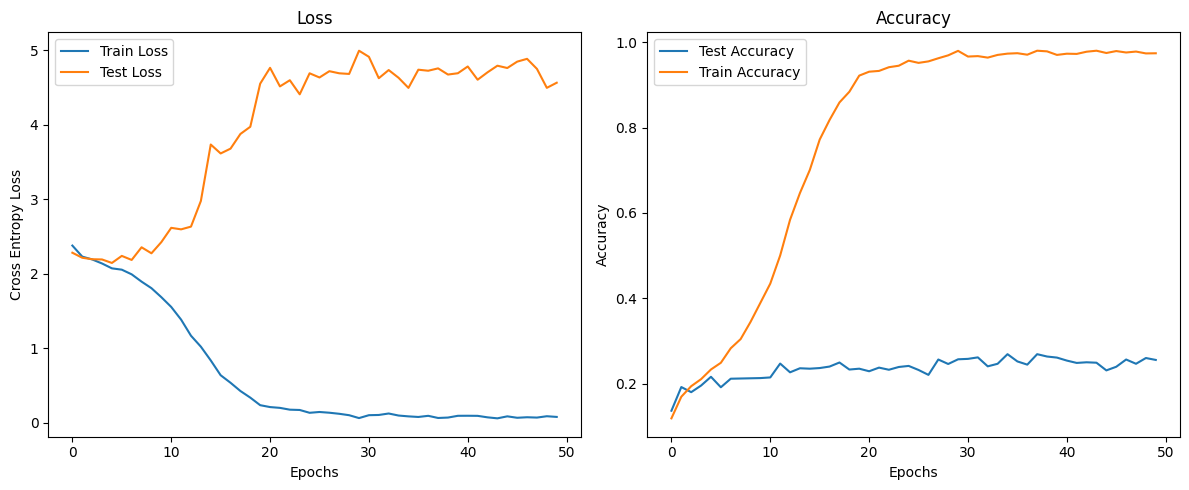

In [7]:
train_ds = specdataset.KClassDataset(len(classvec), train_path)
test_ds = specdataset.KClassDataset(len(classvec), test_path)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

model = TinyResNet(num_classes=len(classvec)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = {'train_loss': [], 'test_loss':[], 'test_acc': [], 'train_acc': []}

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    ts_loss, ts_acc = evaluate(model, test_loader, criterion)
    
    history['train_loss'].append(tr_loss)
    history['test_loss'].append(ts_loss)
    history['test_acc'].append(ts_acc)
    history['train_acc'].append(tr_acc)
    
    print(f"Epoch {epoch+1:02d}: Loss={tr_loss:.4f} | Train Acc={tr_acc:.2%}| Test Acc={ts_acc:.2%}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['test_loss'], label='Test Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Cross Entropy Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['test_acc'], label='Test Accuracy')
plt.plot(history['train_acc'], label='Train Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()